# 03B — Per-region analysis  ·  line B (DS0N)

The `sebastian_sun_spots` datasets, one at a time, through **the same eight steps as
`03A_data_analysis.ipynb`**. Read the two side by side: the step numbers, the function calls
and the figures are the same, because both loaders return the same `data` dict.

What differs is only the entry point and the thresholds:

|  | line A (NOAA) | line B (DS0N) |
|---|---|---|
| loader | `loaders.load_noaa_region` | `loaders.load_ds0n_region` |
| on disk | `region_01_*_cube.fits`, on a uniform grid written by `02A` | IDL-style `cube_*.fits` + `.sav` timing, as delivered |
| thresholds | fractions of each frame's own quiet sun | absolute DN (30 000 / 50 000) |
| corrections | applied here, by `02A` | already applied before delivery |

The two keep **separate loaders on purpose**. Their thresholds mean different things, and
trying to serve both from one function is how the old `sunspot_analysis.py` ended up carrying
two whole pipeline generations at once.

This notebook replaces `03T_data_analisis.ipynb` (now in `archive/`), which was twelve
copy-pasted blocks with the thresholds retyped in each. Here every block reads
`config.params_for(ds_dir, line='B')`.

### Which datasets

`DS00`–`DS09` load. **`DS10`'s `cube_continuum.fits` is truncated** — astropy refuses it with
*"buffer is too small for requested array"* — and **`DS11` has no continuum cube at all**.
Both are listed in `config.DS0N_BROKEN`; re-deliver those two files and add them back to
`config.DS0N_IDS`.

In [2]:
import pathlib
import sys

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
from IPython.display import FileLink

from src import analysis, animation, config, oscillation, spectra
from src.loaders import load_ds0n_region

datasets = config.ds0n_regions()
print(f'{len(datasets)} DS0N dataset(s) with a continuum cube:')
for i, ds_dir in enumerate(datasets):
    print(f'  [{i}] {ds_dir.name}')
for name, why in config.DS0N_BROKEN.items():
    print(f'  --  {name}: {why}')

print('\nThresholds (src/config.py, DS0N_DEFAULTS):')
for key, value in config.DS0N_DEFAULTS.items():
    print(f'  {key:20s} = {value!r}')

10 DS0N dataset(s) with a continuum cube:
  [0] DS00
  [1] DS01
  [2] DS02
  [3] DS03
  [4] DS04
  [5] DS05
  [6] DS06
  [7] DS07
  [8] DS08
  [9] DS09
  --  DS10: cube_continuum.fits is truncated (buffer is too small for requested array)
  --  DS11: no cube_continuum.fits

Thresholds (src/config.py, DS0N_DEFAULTS):
  umbra_thresh         = 30000
  penumbra_thresh      = 50000
  cadence_s            = 720.0
  filter_mask          = False
  mag_filter           = <function <lambda> at 0x7f0837248250>


## Knobs for this run

The same three as `03A`, with the same meanings.

In [3]:
SAVE = False
DOMINANT_PERIOD_MIN = 1440.0
RUN_MU = False

---

# DS00

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 0

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

# DS01

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [4]:
DS_INDEX = 1

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

/mnt/shared/Projects/sun_spots_pulsation_review/src/loaders.py:93: UserWarning: Cadence check failed: 21 gaps deviate from 720.0 s (max deviation 2160.0 s)
  warnings.warn(


(median 720.0 s, max dev 2160.00 s)
DS01
  cube shape (n_t, ny, nx) : (1067, 239, 239)
  time span                : 213.2 h (1067 frames @ 720 s)
  segmentation             : umbra < 30,000, penumbra < 50,000
  umbra     area px        : mean=814  min=570  max=925
  penumbra  area px        : mean=3486  min=2938  max=3920
  hot_spot  area px        : mean=2001  min=1371  max=2242


### Step 2 — Look at what was actually selected before believing any number derived from it.

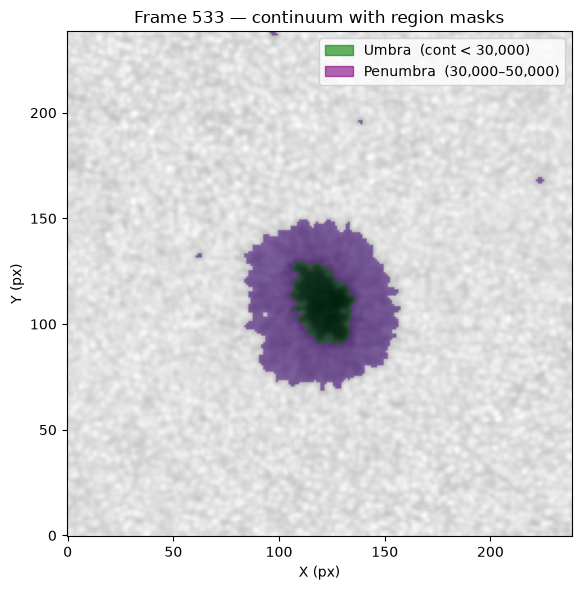

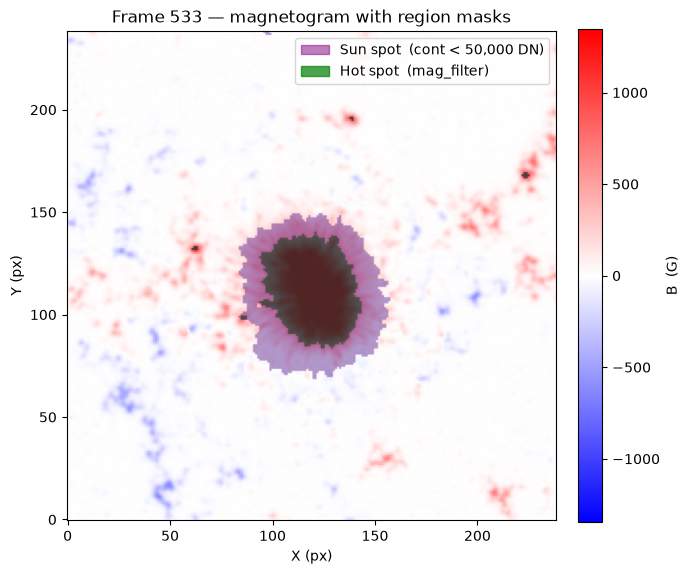

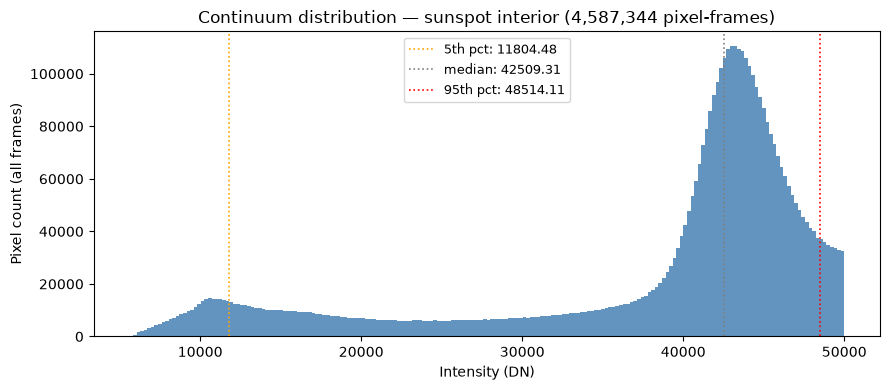

min=5601.71  p1=8422.45  p5=11804.48  p25=36655.77  median=42509.31  p75=44956.32  p95=48514.11  p99=49687.62  max=50000.00


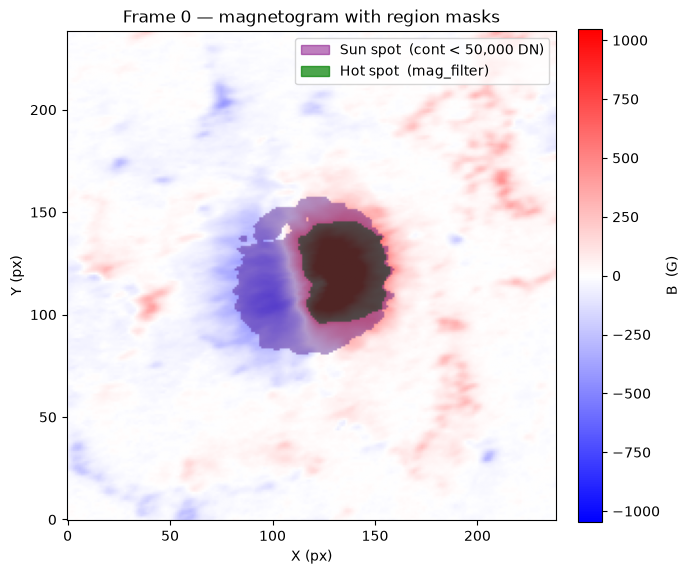

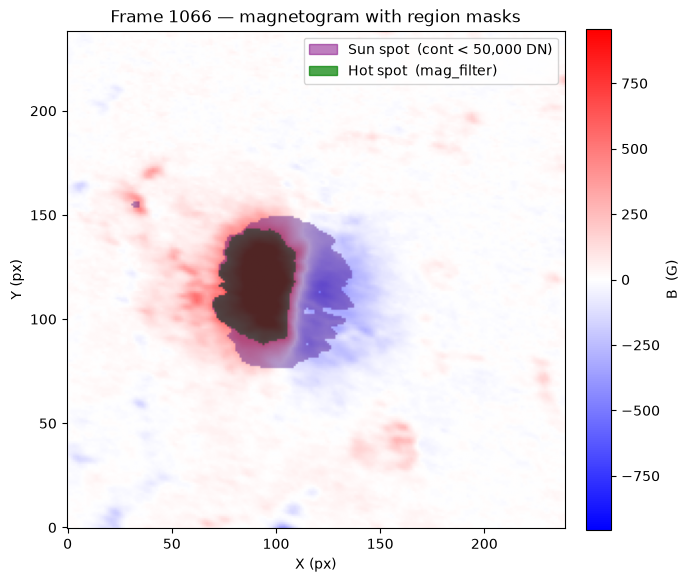

In [5]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [6]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

Metrics saved → /mnt/shared/Projects/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS01/metrics.csv  (1067 rows)
  mean B umbra      :    1273.8 G
  mean v umbra      :     -26.0 m/s
  mean v quiet sun  :    -164.9 m/s
  umbra - quiet     :     138.8 m/s


### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

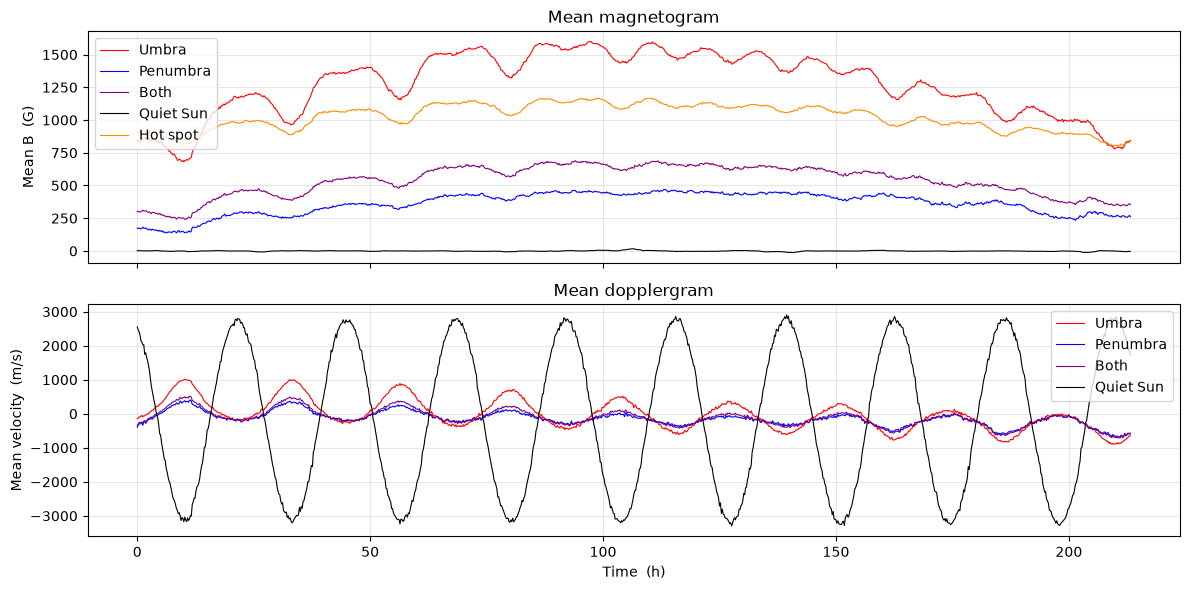

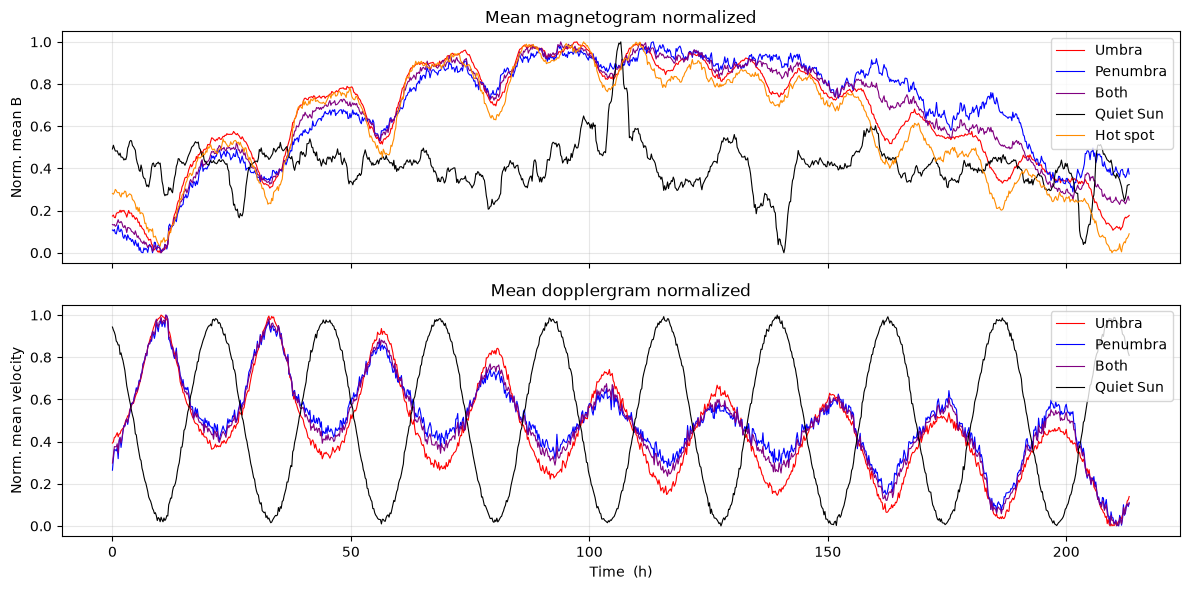

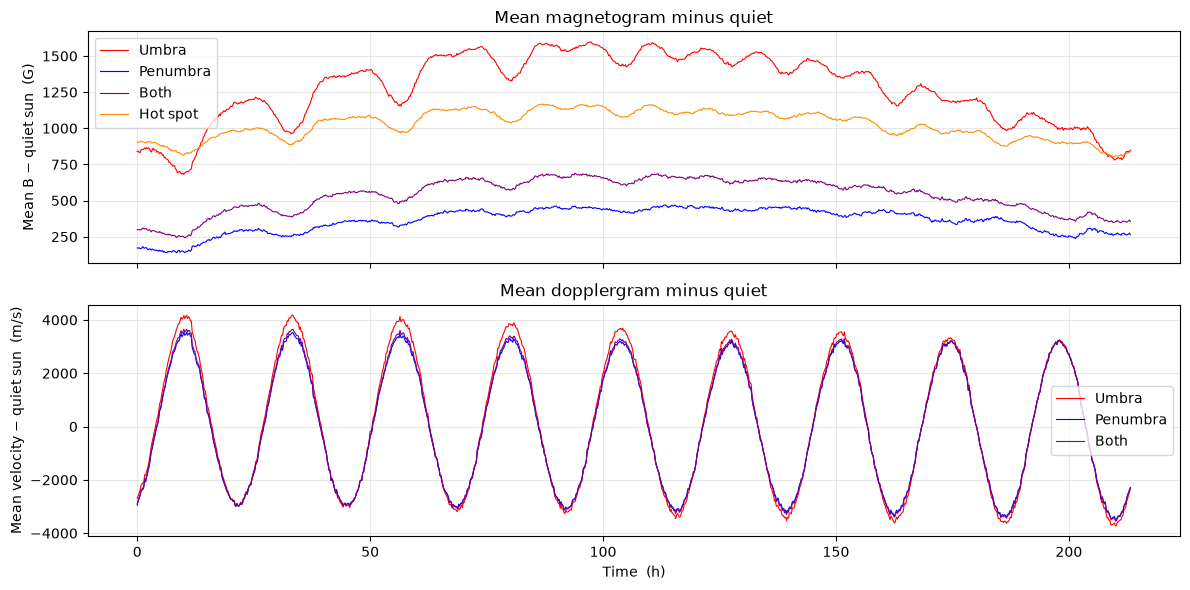

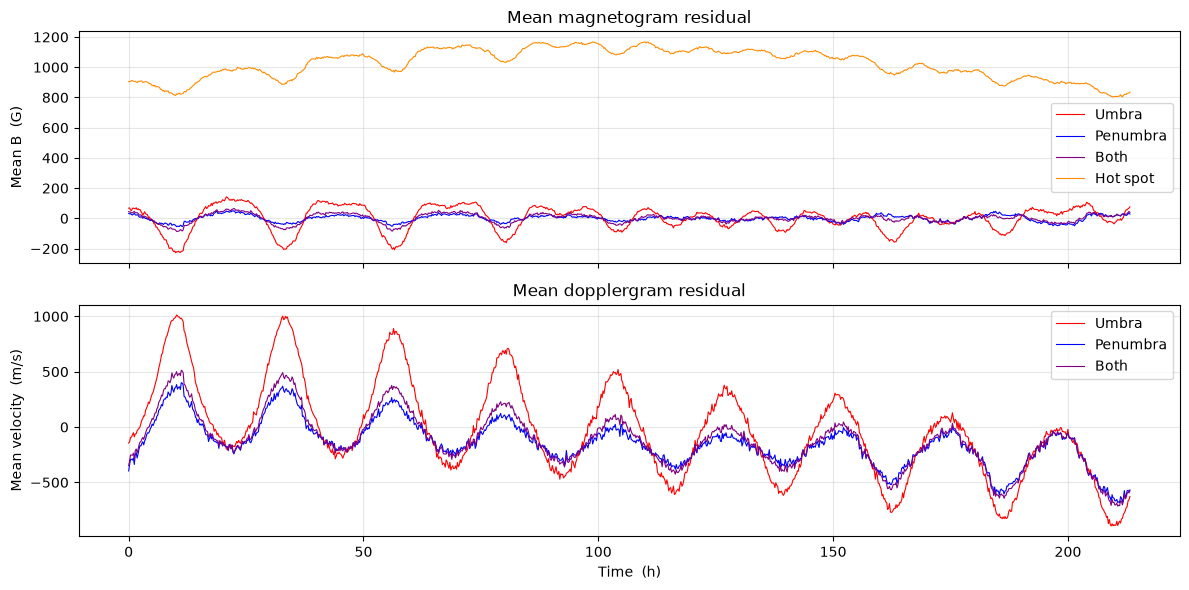

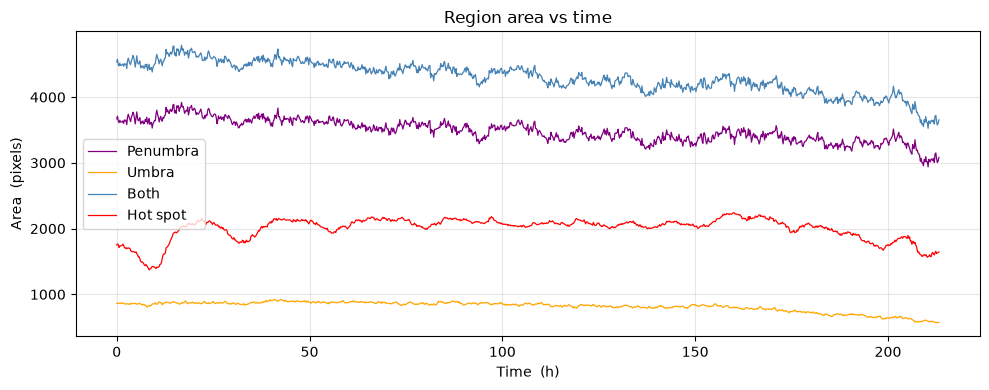

In [7]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, do_not_show_quiet=True, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

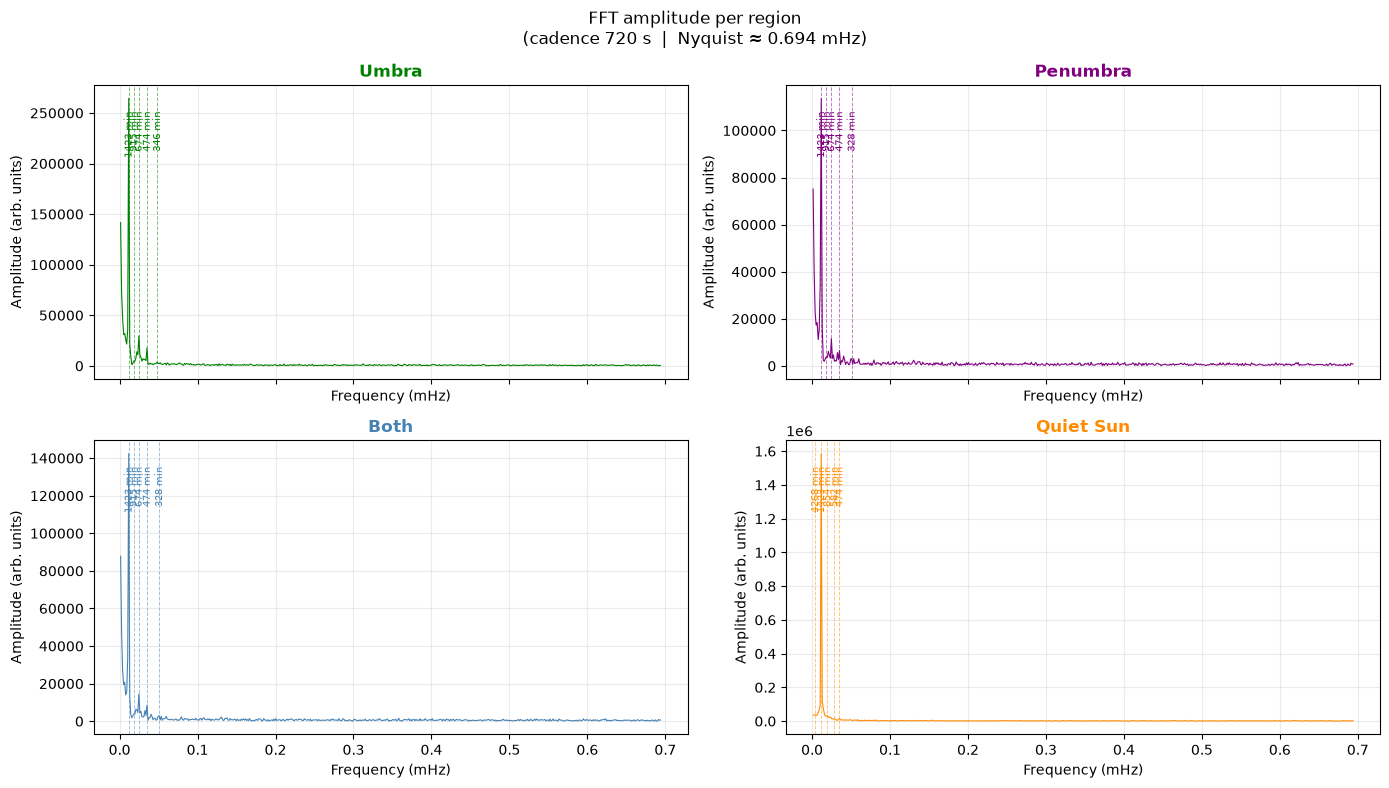


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7          1.0000
Umbra            2       0.0247          673.9          0.1121
Umbra            3       0.0351          474.2          0.0674
Umbra            4       0.0182          914.6          0.0184
Umbra            5       0.0482          346.1          0.0141

Penumbra         1       0.0117         1422.7          1.0000
Penumbra         2       0.0247          673.9          0.1018
Penumbra         3       0.0351          474.2          0.0574
Penumbra         4       0.0182          914.6          0.0338
Penumbra         5       0.0508          328.3          0.0273

Both             1       0.0117         1422.7          1.0000
Both             2       0.0247          673.9          0.1021
Both             3       0.0351          474.2          0.0605
Both             4       0.0182          914.6        

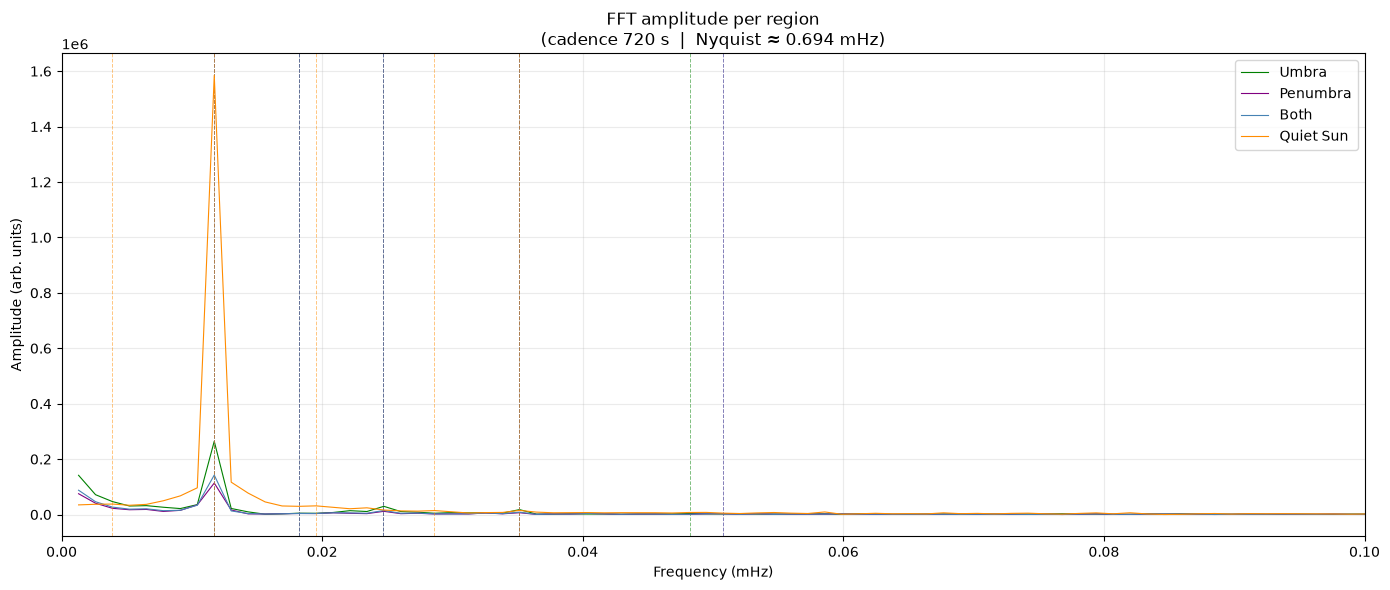


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7          1.0000
Umbra            2       0.0247          673.9          0.1121
Umbra            3       0.0351          474.2          0.0674
Umbra            4       0.0182          914.6          0.0184
Umbra            5       0.0482          346.1          0.0141

Penumbra         1       0.0117         1422.7          1.0000
Penumbra         2       0.0247          673.9          0.1018
Penumbra         3       0.0351          474.2          0.0574
Penumbra         4       0.0182          914.6          0.0338
Penumbra         5       0.0508          328.3          0.0273

Both             1       0.0117         1422.7          1.0000
Both             2       0.0247          673.9          0.1021
Both             3       0.0351          474.2          0.0605
Both             4       0.0182          914.6        

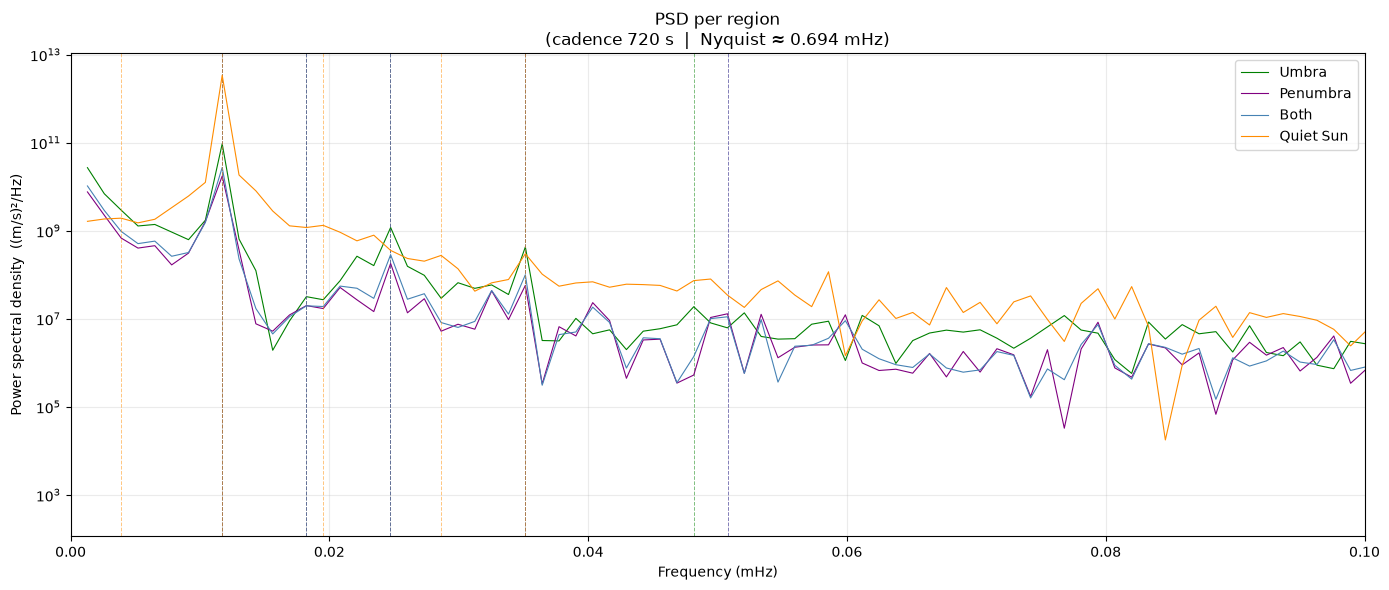


Region        Rank   Freq (mHz)   Period (min)      Rel. power
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7          1.0000
Umbra            2       0.0247          673.9          0.0126
Umbra            3       0.0351          474.2          0.0045
Umbra            4       0.0182          914.6          0.0003
Umbra            5       0.0482          346.1          0.0002

Penumbra         1       0.0117         1422.7          1.0000
Penumbra         2       0.0247          673.9          0.0104
Penumbra         3       0.0351          474.2          0.0033
Penumbra         4       0.0182          914.6          0.0011
Penumbra         5       0.0508          328.3          0.0007

Both             1       0.0117         1422.7          1.0000
Both             2       0.0247          673.9          0.0104
Both             3       0.0351          474.2          0.0037
Both             4       0.0182          914.6        

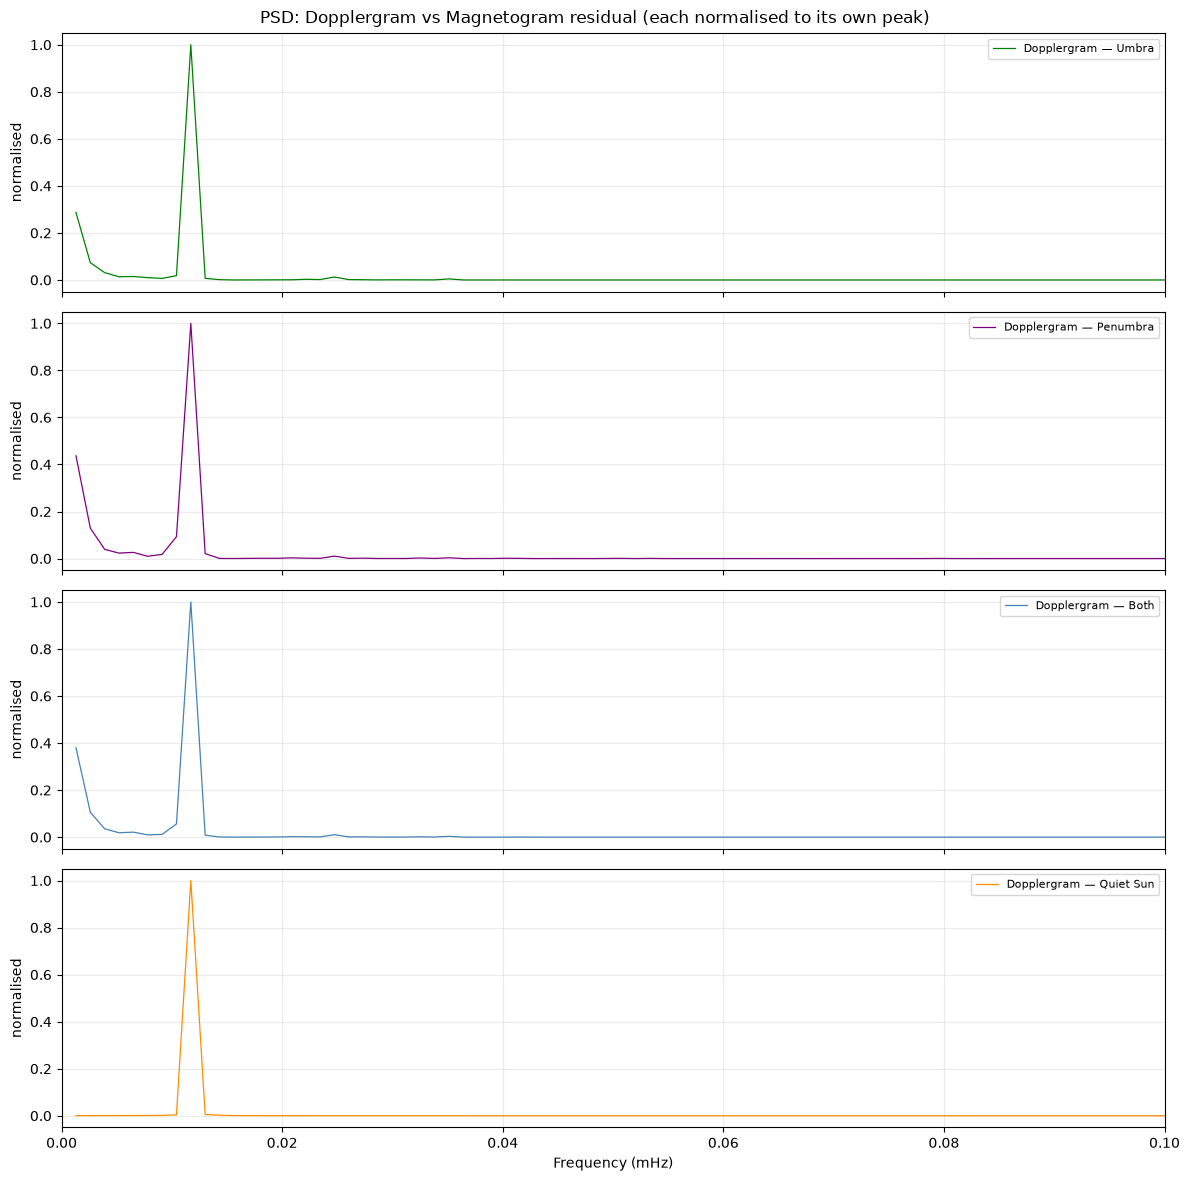

region        amplitude    period   cycles
Umbra            478.2     23.71 h      9.0
Penumbra         166.3     23.39 h      9.1
Both             226.6     23.39 h      9.1
Quiet Sun       2993.4     23.71 h      9.0


In [8]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

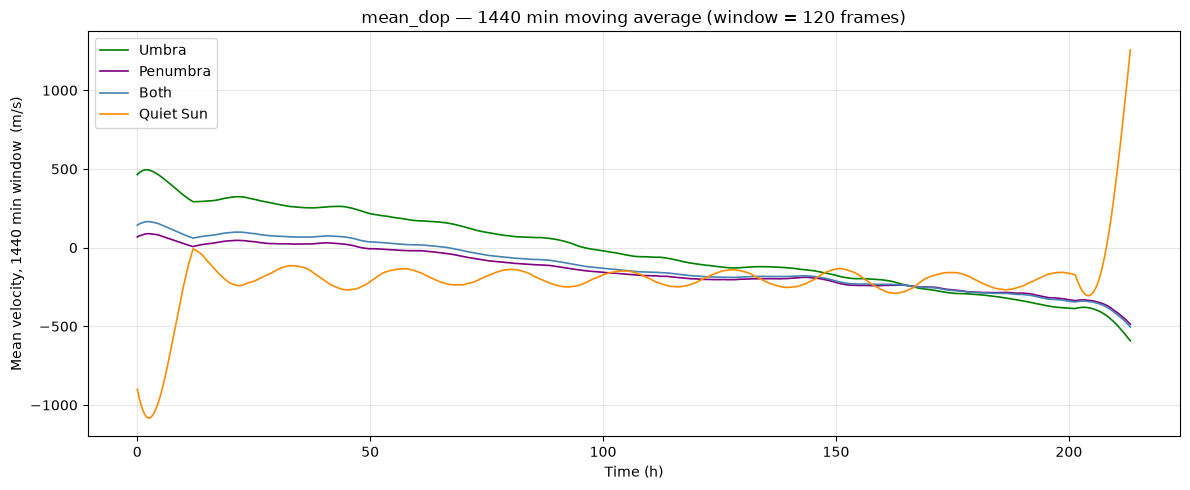

Mean per region after smoothing:
  Umbra     : -19.0 m/s
  Penumbra  : -140.5 m/s
  Both      : -117.0 m/s
  Quiet Sun : -204.7 m/s


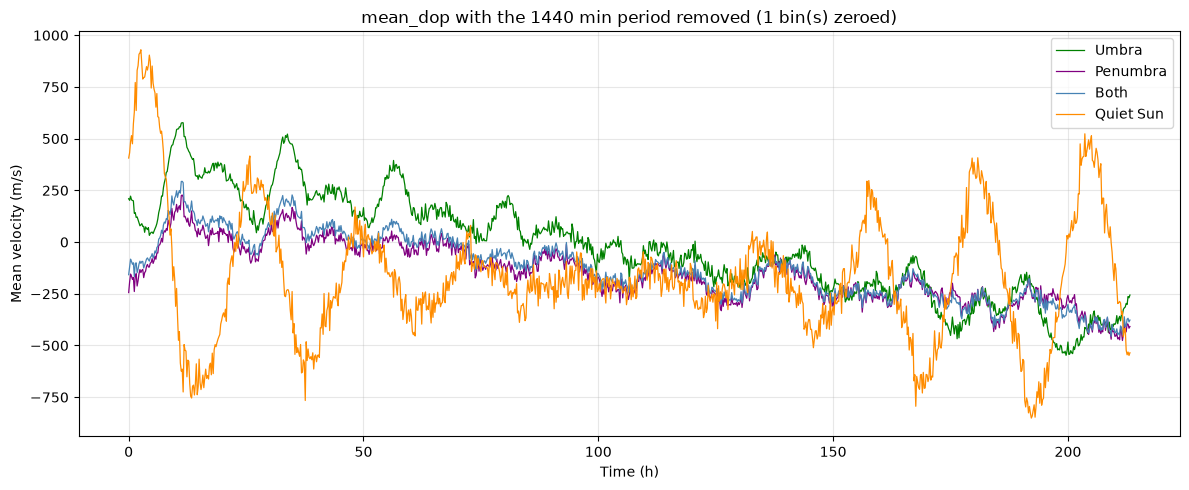

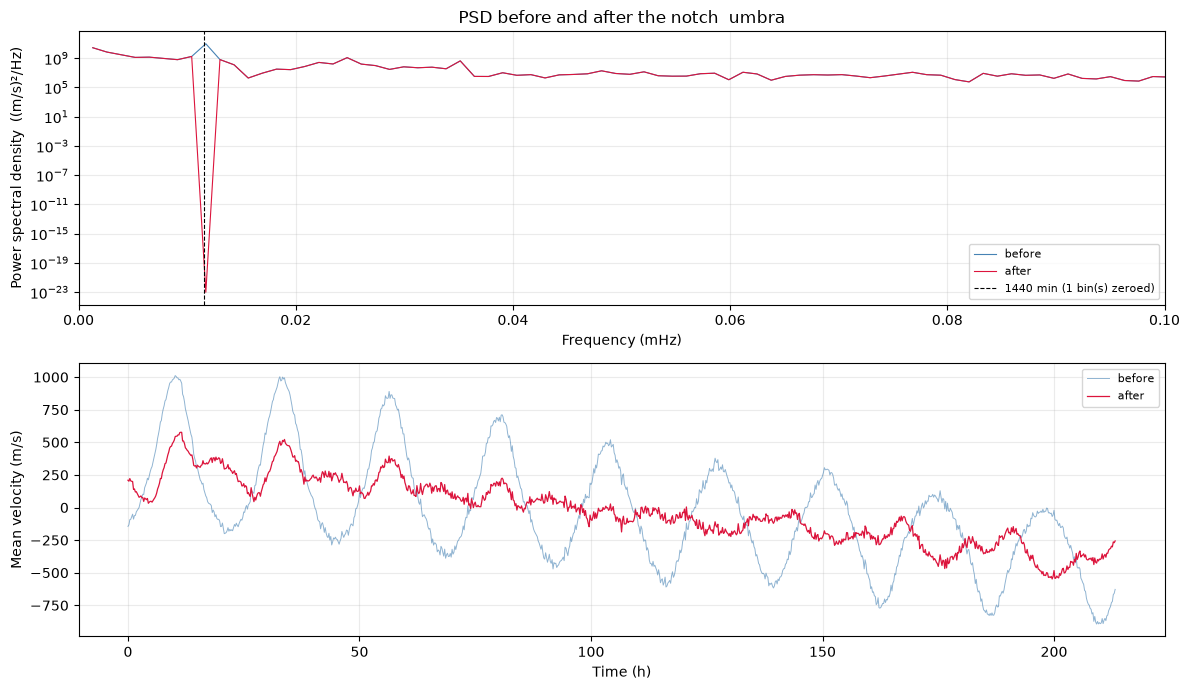

array([ 209.41800246,  201.96785781,  222.03188614, ..., -263.43957361,
       -269.50122633, -256.05910896], shape=(1067,))

In [9]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [10]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

RUN_MU is False — set it in the setup cell to run the geometry check.


### Step 8 — Animation.

In [11]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

Animation saved → /mnt/shared/Projects/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS01/anim.html  (63 frames, 0.0 MB, frames in a sibling directory)


/mnt/shared/Projects/sun_spots_pulsation_review/notebooks/data/processed/sebastian_sun_spots/DS01/anim.html

---

# DS02

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 2

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

# DS03

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 3

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

# DS04

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 4

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

# DS05

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 5

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

# DS06

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 6

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

# DS07

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 7

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

# DS08

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 8

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

# DS09

### Step 1 — Verify the cadence, load the cubes, build the regions. `params` comes from `config.DS0N_DEFAULTS`.

In [ ]:
DS_INDEX = 9

ds_dir     = datasets[DS_INDEX]
out_dir    = config.DS0N_PROCESSED_DIR / ds_dir.name
plots_dir  = out_dir / 'plots'

params = config.params_for(ds_dir, line='B')
view   = config.view_params(params)

from src.loaders import verify_cadence
verify_cadence(ds_dir, expected_s=params['cadence_s'])

data = load_ds0n_region(ds_dir, **config.loader_kwargs(params))

print(ds_dir.name)
report = analysis.describe_region(data)

### Step 2 — Look at what was actually selected before believing any number derived from it.

In [ ]:
analysis.plot_calibration_frame(data, frame_idx=view['frame_idx'], save=SAVE, plots_dir=plots_dir)
analysis.plot_magnetogram_masks(data, frame_idx=view['frame_idx_masks'], save=SAVE, plots_dir=plots_dir)
analysis.plot_histogram(data, cube='continuum', save=SAVE, plots_dir=plots_dir)

for idx in (0, data['n_t'] - 1):
    analysis.plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

### Step 3 — Per-frame means over each mask, plus the parabola-subtracted magnetogram residual, written to `metrics.csv` for `04`.

In [ ]:
metrics = analysis.compute_metrics(data)
metrics = analysis.add_mag_residuals(data, metrics)
analysis.save_metrics_csv(data, metrics, out_dir)

umb, quiet = metrics['mean_dop_umb'], metrics['mean_dop_quiet']
print(f"  mean B umbra      : {np.nanmean(metrics['mean_mag_umb']):9.1f} G")
print(f"  mean v umbra      : {np.nanmean(umb):9.1f} m/s")
print(f"  mean v quiet sun  : {np.nanmean(quiet):9.1f} m/s")
print(f"  umbra - quiet     : {np.nanmean(umb - quiet):9.1f} m/s")

### Step 4 — Raw, normalised, quiet-sun-subtracted and magnetogram-residual views.

In [ ]:
analysis.plot_time_series(data, metrics, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, normalized=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, subtract_quiet=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_time_series(data, metrics, mag_residual=True, save=SAVE, plots_dir=plots_dir)
analysis.plot_area(data, metrics, save=SAVE, plots_dir=plots_dir)

### Step 5 — Spectra.

In [ ]:
cadence_s = data['cadence_s']

fft = spectra.region_spectra(metrics, cadence_s, kind='fft')
spectra.plot_spectra_separate(fft, cadence_s, kind='fft', save=SAVE, plots_dir=plots_dir)
spectra.plot_spectra_combined(fft, cadence_s, kind='fft', xlim=(0, 0.1),
                              save=SAVE, plots_dir=plots_dir)

psd = spectra.region_spectra(metrics, cadence_s, kind='psd')
spectra.plot_spectra_combined(psd, cadence_s, kind='psd', xlim=(0, 0.1), log_y=True,
                              save=SAVE, plots_dir=plots_dir)

psd_mag = spectra.region_spectra(metrics, cadence_s, kind='psd', key='mean_mag_residual')
spectra.plot_spectra_compare(psd, psd_mag, cadence_s, label_a='Dopplergram',
                             label_b='Magnetogram residual', kind='psd', normalize=True,
                             xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

print(f'{"region":<12} {"amplitude":>10} {"period":>9} {"cycles":>8}')
for label, suffix, _ in spectra.DEFAULT_REGIONS:
    series = metrics.get(f'mean_dop_{suffix}')
    if series is None:
        continue
    result = spectra.band_amplitude(data['time_h'], series)
    print(f'{label:<12} {result["amplitude"]:9.1f}  {result["period_h"]:8.2f} h '
          f'{result["n_cycles"]:8.1f}')

### Step 6 — Detrending — what is left once the dominant period is taken out.

In [ ]:
oscillation.plot_moving_average(data, metrics, window_min=DOMINANT_PERIOD_MIN,
                                save=SAVE, plots_dir=plots_dir)
oscillation.plot_filtered(data, metrics, period_min=DOMINANT_PERIOD_MIN,
                          save=SAVE, plots_dir=plots_dir)
spectra.plot_spectrum_before_after(metrics['mean_dop_umb'], data['cadence_s'],
                                   period_min=DOMINANT_PERIOD_MIN, label='umbra',
                                   xlim=(0, 0.1), save=SAVE, plots_dir=plots_dir)

### Step 7 — Is the slow magnetogram trend just geometry?

In [ ]:
# DS0N ships `cube_mu.fits`, so the geometry check is cheap here — no map loading needed,
# unlike line A where mu has to be computed frame by frame.
if RUN_MU and (ds_dir / 'cube_mu.fits').exists():
    cube_mu = analysis.mu_cube_ds0n(ds_dir)
    mu_means, mu_fits = analysis.plot_mu_means(cube_mu, data, save=SAVE, plots_dir=plots_dir)
    analysis.plot_mu_vs_trend(data, metrics, mu_means, key='mean_mag',
                              save=SAVE, plots_dir=plots_dir)
elif not RUN_MU:
    print('RUN_MU is False — set it in the setup cell to run the geometry check.')
else:
    print(f'{ds_dir.name} has no cube_mu.fits')

### Step 8 — Animation.

In [ ]:
anim_path = animation.save_animation(data, metrics, out_dir / 'anim.html',
                                     step=max(1, data['n_t'] // 60), fps=5,
                                     mag_symmetric_cbar=True)
FileLink(str(pathlib.Path(anim_path).relative_to(project_root)))

---

## Next

`04_data_comparison.ipynb` reads the `metrics.csv` files written in step 3 and compares the
datasets to each other — and to line A.